# Machine Learning Models Comparison
## Neural Network, SVM, and Decision Tree Implementation


** Usar PyTorch :**
```bash
pip install torch torchvision
```

```bash
pip install scikit-learn pandas matplotlib seaborn numpy
```
```bash
pip install tensorflow-cpu==2.20.0
```

In [181]:
#import sys
#!{sys.executable} -m pip install tensorflow




In [182]:
#import sys
#!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn


In [183]:
import tensorflow as tf
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Data Loading and Preprocessing

In [184]:

data = pd.read_csv('DOMensalEstadoDesde1991.csv', sep=';')




In [185]:
data

,ano,mes,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,letalidade_violenta,tentat_hom,lesao_corp_dolosa,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1991,1,657,NaN,15,NaN,NaN,672,162,3051,...,NaN,NaN,NaN,NaN,217,NaN,NaN,NaN,NaN,3
1,1991,2,732,NaN,17,NaN,NaN,749,175,3421,...,NaN,NaN,NaN,NaN,209,NaN,NaN,NaN,NaN,3
2,1991,3,713,NaN,25,NaN,NaN,738,216,3613,...,NaN,NaN,NaN,NaN,188,NaN,NaN,NaN,NaN,3
3,1991,4,634,NaN,20,NaN,NaN,654,200,3211,...,NaN,NaN,NaN,NaN,140,NaN,NaN,NaN,NaN,3
4,1991,5,650,NaN,20,NaN,NaN,670,146,3051,...,NaN,NaN,NaN,NaN,78,NaN,NaN,NaN,NaN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
411,2025,4,211,6.0,9,226.0,83.0,309,292,4986,...,933.0,105.0,5498.0,498.0,31,1.0,0.0,0.0,75761.0,3
412,2025,5,257,5.0,4,266.0,44.0,310,278,4962,...,1022.0,115.0,5559.0,496.0,37,5.0,1.0,1.0,80423.0,3
413,2025,6,219,5.0,1,225.0,45.0,270,294,4938,...,909.0,112.0,5279.0,492.0,38,0.0,0.0,0.0,77260.0,3
414,2025,7,178,4.0,8,190.0,47.0,237,269,4755,...,1003.0,116.0,5413.0,486.0,36,7.0,2.0,0.0,83127.0,2


In [186]:
# Verificar valores ausentes
missing_values = data.isnull().sum()
missing_summary = missing_values[missing_values > 0]

print("Valores ausentes por coluna:")
print(missing_summary)

Valores ausentes por coluna:
lesao_corp_morte               96
cvli                           96
hom_por_interv_policial        84
estupro                       144
hom_culposo                    84
lesao_corp_culposa             96
roubo_celular                 108
roubo_cx_eletronico           144
roubo_conducao_saque          144
roubo_apos_saque              144
roubo_bicicleta               276
furto_coletivo                144
furto_celular                 144
furto_bicicleta               276
sequestro                      96
extorsao                      144
sequestro_relampago           144
estelionato                   144
posse_drogas                  180
trafico_drogas                180
apreensao_drogas_sem_autor    180
apf                           180
aaapai                        180
cmp                           180
cmba                          180
ameaca                         96
pessoas_desaparecidas         132
encontro_ossada               132
pol_militares_morto

In [187]:
# Informações gerais
print(f"\nInformações do dataset:")
print(f"- Registros: {len(data):,}")
print(f"- Colunas: {len(data.columns)}")
print(f"- Tipos de dados:")
print(data.dtypes.value_counts())

# Mostrar algumas estatísticas
data.describe()


Informações do dataset:
- Registros: 416
- Colunas: 56
- Tipos de dados:
float64    31
int64      25
Name: count, dtype: int64


,ano,mes,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,letalidade_violenta,tentat_hom,lesao_corp_dolosa,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
count,416.000000,416.000000,416.000000,320.000000,416.000000,320.000000,332.000000,416.000000,416.000000,416.000000,...,236.000000,236.000000,320.000000,284.000000,416.000000,284.000000,272.000000,272.000000,320.000000,416.000000
mean,2007.836538,6.461538,463.668269,4.250000,14.165865,434.121875,76.003012,541.759615,318.939904,5387.713942,...,1188.970339,86.199153,5381.612500,431.468310,59.901442,3.161972,1.808824,0.294118,56085.778125,2.995192
std,10.020808,3.448549,137.761399,2.681645,6.400594,116.850308,37.777653,126.842944,118.101830,1430.189787,...,344.803384,62.239880,1093.088521,75.548237,34.835343,2.191011,1.668084,0.596641,12047.997305,0.069254
min,1991.000000,1.000000,178.000000,0.000000,1.000000,190.000000,10.000000,237.000000,122.000000,2350.000000,...,544.000000,2.000000,1409.000000,178.000000,0.000000,0.000000,0.000000,0.000000,30621.000000,2.000000
25%,1999.000000,3.000000,350.000000,2.000000,10.000000,337.750000,45.000000,444.750000,212.000000,4401.000000,...,908.250000,46.000000,4744.000000,385.750000,35.000000,2.000000,1.000000,0.000000,47675.000000,3.000000
50%,2008.000000,6.000000,471.000000,4.000000,13.000000,438.500000,74.000000,557.000000,320.500000,5589.000000,...,1120.500000,61.000000,5368.000000,427.000000,50.000000,3.000000,1.000000,0.000000,56359.000000,3.000000
75%,2016.250000,9.000000,557.250000,6.000000,18.000000,532.250000,101.000000,638.000000,386.250000,6443.750000,...,1443.500000,109.000000,6048.000000,486.250000,80.000000,4.000000,3.000000,0.000000,65278.250000,3.000000
max,2025.000000,12.000000,831.000000,21.000000,36.000000,710.000000,195.000000,848.000000,645.000000,9050.000000,...,2314.000000,350.000000,9034.000000,628.000000,217.000000,13.000000,10.000000,3.000000,84129.000000,3.000000


In [188]:
# Fazer uma cópia para processamento
df_processed = data.copy()


In [189]:
# Substituir valores NaN por 0 (assumindo que são crimes não ocorridos)
numeric_columns = df_processed.select_dtypes(include=[np.number]).columns
df_processed[numeric_columns] = df_processed[numeric_columns].fillna(0)

In [190]:
# Converter colunas que devem ser numéricas
for col in df_processed.columns:
    if col not in ['data', 'fase']:  # Excluir colunas de data/texto
        try:
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
            df_processed[col] = df_processed[col].fillna(0)
        except:
            pass


## FEATURES

In [191]:
# Taxa de recuperação de veículos
if 'recuperacao_veiculos' in df_processed.columns and 'roubo_veiculo' in df_processed.columns:
    df_processed['taxa_recuperacao_veiculos'] = (df_processed['recuperacao_veiculos'] / 
                                               (df_processed['roubo_veiculo'] + df_processed['furto_veiculos'] + 1))

# Eficiência em apreensão de drogas
drug_columns = [col for col in df_processed.columns if 'droga' in col.lower()]
if drug_columns:
    df_processed['total_operacoes_drogas'] = df_processed[drug_columns].sum(axis=1)

# Taxa de mortalidade policial
police_death_cols = [col for col in df_processed.columns if 'policial' in col.lower() and 'mort' in col.lower()]
if police_death_cols:
    df_processed['total_policiais_mortos'] = df_processed[police_death_cols].sum(axis=1)

In [192]:
#FEATURES DE TENDÊNCIA E VOLATILIDADE

# Ordenar por ano e mês para calcular tendências
if 'ano' in df_processed.columns and 'mes' in df_processed.columns:
    df_processed = df_processed.sort_values(['ano', 'mes'])
    
    # Exemplo seguro: tendência de homicídios dolosos (não causa leakage)
    window = 3  # 3 meses
    if 'hom_doloso' in df_processed.columns:
        df_processed['hom_doloso_ma3'] = df_processed['hom_doloso'].rolling(window=window, min_periods=1).mean()
        df_processed['hom_doloso_tendencia'] = df_processed['hom_doloso'] - df_processed['hom_doloso_ma3']
        df_processed['hom_doloso_volatilidade'] = df_processed['hom_doloso'].rolling(window=6, min_periods=1).std().fillna(0)

In [193]:
# Categorizar homicídios
if 'hom_doloso' in df_processed.columns:
    df_processed['alto_homicidio'] = (df_processed['hom_doloso'] > 
                                    df_processed['hom_doloso'].quantile(0.75)).astype(int)

In [194]:
# FEATURES ESPECÍFICAS POR TIPO DE LOCAL


# Crimes em estabelecimentos vs. via pública
establishment_crimes = ['roubo_comercio', 'roubo_banco', 'roubo_residencia']
establishment_crimes = [col for col in establishment_crimes if col in df_processed.columns]

street_crimes = ['roubo_transeunte', 'roubo_celular', 'roubo_rua']
street_crimes = [col for col in street_crimes if col in df_processed.columns]

if establishment_crimes:
    df_processed['crimes_estabelecimentos'] = df_processed[establishment_crimes].sum(axis=1)

if street_crimes:
    df_processed['crimes_via_publica'] = df_processed[street_crimes].sum(axis=1)

if establishment_crimes and street_crimes:
    df_processed['razao_estabelecimento_rua'] = (df_processed['crimes_estabelecimentos'] / 
                                               (df_processed['crimes_via_publica'] + 1))

In [195]:
# FEATURES DE RISCO E SEGURANÇA


# Índice de risco geral
risk_factors = ['hom_doloso', 'latrocinio', 'sequestro', 'estupro']
risk_factors = [col for col in risk_factors if col in df_processed.columns]

if risk_factors:
    df_processed['indice_risco'] = df_processed[risk_factors].sum(axis=1)
    df_processed['risco_normalizado'] = (df_processed['indice_risco'] - df_processed['indice_risco'].min()) / \
                                      (df_processed['indice_risco'].max() - df_processed['indice_risco'].min() + 1)

# Segurança patrimonial
if 'recuperacao_veiculos' in df_processed.columns and 'total_crimes_patrimonio' in df_processed.columns:
    df_processed['efetividade_recuperacao'] = (df_processed['recuperacao_veiculos'] / 
                                             (df_processed['total_crimes_patrimonio'] + 1))



# Visualização dos dados


## 2. Neural Network Implementation
Implementação com múltiplos backends (TensorFlow, PyTorch, ou Scikit-learn)

In [196]:
# Célula corrigida: Preparação dos dados para Machine Learning
from sklearn.feature_selection import SelectKBest, f_classif

# Escolha a feature agregada que representa criminalidade
target_base = 'indice_risco'  # ou outra coluna agregada existente

if target_base not in df_processed.columns:
    raise KeyError(f"Coluna '{target_base}' não encontrada em df_processed. Verifique as features agregadas.")

median_crimes = df_processed[target_base].median()
df_processed['target_criminalidade'] = (df_processed[target_base] > median_crimes).astype(int)
target_column = 'target_criminalidade'

print(f"Target criado: {target_column} (baseado em {target_base})")
print(f"Mediana de {target_base}: {median_crimes}")
print(f"Distribuição do target: {df_processed[target_column].value_counts()}")

# Separar features e target
y = df_processed[target_column]

# Verificar quais colunas existem antes de removê-las
columns_to_remove = [target_column]
optional_columns = ['data', 'fase', 'nivel_criminalidade']

for col in optional_columns:
    if col in df_processed.columns:
        columns_to_remove.append(col)
        print(f"Removendo coluna: {col}")

print(f"Colunas a serem removidas: {columns_to_remove}")

# Criar X removendo as colunas identificadas
X = df_processed.drop(columns=columns_to_remove)

print(f"Shape inicial de X: {X.shape}")

# Manter apenas colunas numéricas
numeric_columns = X.select_dtypes(include=[np.number]).columns
X_numeric = X[numeric_columns]

print(f"Colunas numéricas mantidas: {len(numeric_columns)}")
print(f"Shape após filtro numérico: {X_numeric.shape}")

# Verificar e limpar dados problemáticos
print("Verificando dados problemáticos...")
print(f"Valores infinitos: {np.isinf(X_numeric).sum().sum()}")
print(f"Valores NaN: {X_numeric.isna().sum().sum()}")

# Limpar valores infinitos e NaN
X_clean = X_numeric.replace([np.inf, -np.inf], np.nan)
X_clean = X_clean.fillna(0)

print(f"Shape final: {X_clean.shape}")

# Seleção de features (opcional, pode ajustar k)
k = min(15, X_clean.shape[1])
selector = SelectKBest(score_func=f_classif, k=k)
X_selected = selector.fit_transform(X_clean, y)
feature_names = X_clean.columns[selector.get_support()].tolist()

print(f"Features selecionadas: {feature_names}")
print(f"Shape final para ML: {X_selected.shape}")

Target criado: target_criminalidade (baseado em indice_risco)
Mediana de indice_risco: 750.0
Distribuição do target: target_criminalidade
0    209
1    207
Name: count, dtype: int64
Removendo coluna: fase
Colunas a serem removidas: ['target_criminalidade', 'fase']
Shape inicial de X: (416, 66)
Colunas numéricas mantidas: 66
Shape após filtro numérico: (416, 66)
Verificando dados problemáticos...
Valores infinitos: 0
Valores NaN: 0
Shape final: (416, 66)
Features selecionadas: ['tentat_hom', 'lesao_corp_dolosa', 'estupro', 'roubo_transeunte', 'roubo_rua', 'roubo_apos_saque', 'total_roubos', 'furto_coletivo', 'outros_furtos', 'total_furtos', 'ameaca', 'pessoas_desaparecidas', 'crimes_via_publica', 'indice_risco', 'risco_normalizado']
Shape final para ML: (416, 15)


In [197]:
# Célula: Divisão treino/teste e normalização
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Normalização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Dados preparados para treinamento:")
print(f"   Training set: {X_train_scaled.shape}")
print(f"   Test set: {X_test_scaled.shape}")
print(f"   Features: {len(feature_names)}")
print(f"   Classes: {len(np.unique(y))}")

# Verificar balanceamento das classes
print(f"\nDistribuição das classes:")
print(f"Treino: Classe 0: {(y_train==0).sum()} | Classe 1: {(y_train==1).sum()}")
print(f"Teste:  Classe 0: {(y_test==0).sum()} | Classe 1: {(y_test==1).sum()}")

# Definir nomes das classes para relatórios
target_names = ['Baixa Criminalidade', 'Alta Criminalidade']

# Definir backend da rede neural
NEURAL_NETWORK_BACKEND = "tensorflow"
MATPLOTLIB_AVAILABLE = True
SEABORN_AVAILABLE = True

print(f"Backend Neural Network: {NEURAL_NETWORK_BACKEND}")

✅ Dados preparados para treinamento:
   Training set: (332, 15)
   Test set: (84, 15)
   Features: 15
   Classes: 2

Distribuição das classes:
Treino: Classe 0: 167 | Classe 1: 165
Teste:  Classe 0: 42 | Classe 1: 42
Backend Neural Network: tensorflow


In [198]:
# Implementação da Rede Neural baseada na Dimensão VC e Regra de Ouro
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
import math

# Parâmetros do dataset
N_samples = len(X_train_scaled)
d_features = X_train_scaled.shape[1]

# Aplicação da Regra de Ouro: N ≥ 10 * VC_dim
max_vc_dim = N_samples // 10

# Função para calcular VC dimension: VC_dim ≈ W * log2(W)
def vc_dimension(total_weights):
    if total_weights <= 0:
        return 0
    return total_weights * math.log2(max(total_weights, 2))

# Testar arquiteturas válidas
architectures = [
    [d_features, 4, 1],
    [d_features, 8, 1], 
    [d_features, 16, 1],
    [d_features, 32, 1],
    [d_features, 16, 8, 1],
    [d_features, 32, 16, 1],
]

chosen_arch = None
for arch in architectures:
    # Calcular total de pesos (incluindo bias)
    total_weights = 0
    for i in range(len(arch) - 1):
        weights = arch[i] * arch[i + 1]  # pesos
        bias = arch[i + 1]  # bias por neurônio
        total_weights += weights + bias
    
    # Verificar se atende a Regra de Ouro
    vc_dim = vc_dimension(total_weights)
    if vc_dim <= max_vc_dim:
        chosen_arch = arch
    else:
        break

# Se nenhuma arquitetura válida, usar mínima
if chosen_arch is None:
    chosen_arch = [d_features, 2, 1]



### Fundamentação Teórica

**Dimensão VC:** VC_dim ≈ W × log₂(W), onde W = número total de pesos  
**Regra de Ouro:** N ≥ 10 × VC_dim para boa generalização  
**Teorema da Aproximação Universal:** 1 camada oculta é suficiente para aproximar funções contínuas

In [199]:
# Criar modelo com arquitetura calculada
model = tf.keras.Sequential()

# Adicionar camadas ocultas
hidden_layers = chosen_arch[1:-1]
for i, neurons in enumerate(hidden_layers):
    if i == 0:
        model.add(Dense(neurons, input_dim=d_features, 
                       kernel_initializer='he_normal', activation='relu'))
    else:
        model.add(Dense(neurons, kernel_initializer='he_normal', activation='relu'))
    
    if neurons >= 8:
        model.add(BatchNormalization())
        model.add(Dropout(0.2))

# Camada de saída
model.add(Dense(1, kernel_initializer='glorot_normal', activation='sigmoid'))



c:\Users\Lenovo\Desktop\projeto_2\ML_PROJETO_FINAL\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [200]:
# Compilar modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=0
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=0.0001,
        verbose=0
    )
]

# Treinar modelo
history = model.fit(
    X_train_scaled, y_train,
    batch_size=32,
    epochs=100,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=0
)



In [201]:
# Avaliar modelo
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Arquitetura escolhida: {chosen_arch}")
print(f"Accuracy no teste: {test_accuracy:.4f}")

nn_model = model

Arquitetura escolhida: [15, 2, 1]
Accuracy no teste: 0.8929


c:\Users\Lenovo\Desktop\projeto_2\ML_PROJETO_FINAL\.venv\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\Lenovo\Desktop\projeto_2\ML_PROJETO_FINAL\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


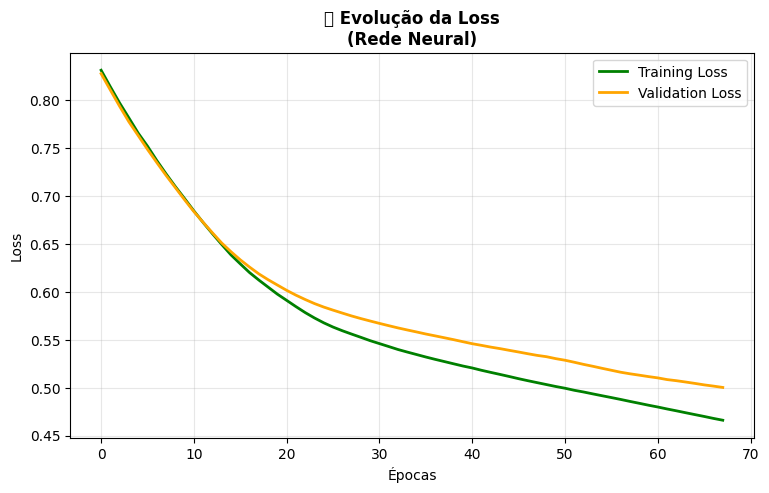

In [202]:
plt.figure(figsize=(30, 5))
#  Loss durante o treinamento
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss', color='green', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('📉 Evolução da Loss\n(Rede Neural)', fontsize=12, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)



In [203]:
# Cálculo de Ein e Eout da Rede Neural
from sklearn.metrics import accuracy_score, log_loss

# Predições
nn_train_pred_proba = nn_model.predict(X_train_scaled, verbose=0)
nn_train_pred = (nn_train_pred_proba > 0.5).astype(int).flatten()

nn_test_pred_proba = nn_model.predict(X_test_scaled, verbose=0)
nn_test_pred = (nn_test_pred_proba > 0.5).astype(int).flatten()

# Calcular métricas
ein_accuracy = accuracy_score(y_train, nn_train_pred)
ein_loss = log_loss(y_train, nn_train_pred_proba)

eout_accuracy = accuracy_score(y_test, nn_test_pred)
eout_loss = log_loss(y_test, nn_test_pred_proba)

print(f"Ein - Accuracy: {ein_accuracy:.4f}, Loss: {ein_loss:.4f}")
print(f"Eout - Accuracy: {eout_accuracy:.4f}, Loss: {eout_loss:.4f}")
print(f"Diferença (Eout - Ein): {eout_accuracy - ein_accuracy:.4f}")

Ein - Accuracy: 0.8554, Loss: 0.5004
Eout - Accuracy: 0.8929, Loss: 0.5213
Diferença (Eout - Ein): 0.0374


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26060\958012947.py:14: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Lenovo\Desktop\projeto_2\ML_PROJETO_FINAL\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


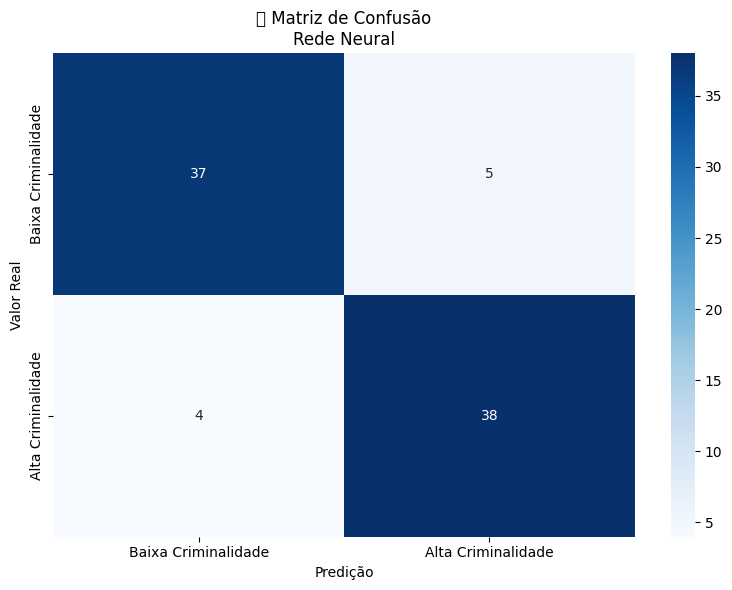

In [204]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_array, nn_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baixa Criminalidade', 'Alta Criminalidade'],
            yticklabels=['Baixa Criminalidade', 'Alta Criminalidade'],
            cbar=True)
plt.title('🔍 Matriz de Confusão\nRede Neural')
plt.xlabel('Predição')
plt.ylabel('Valor Real')
plt.tight_layout()
plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26060\1033761882.py:27: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Lenovo\Desktop\projeto_2\ML_PROJETO_FINAL\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


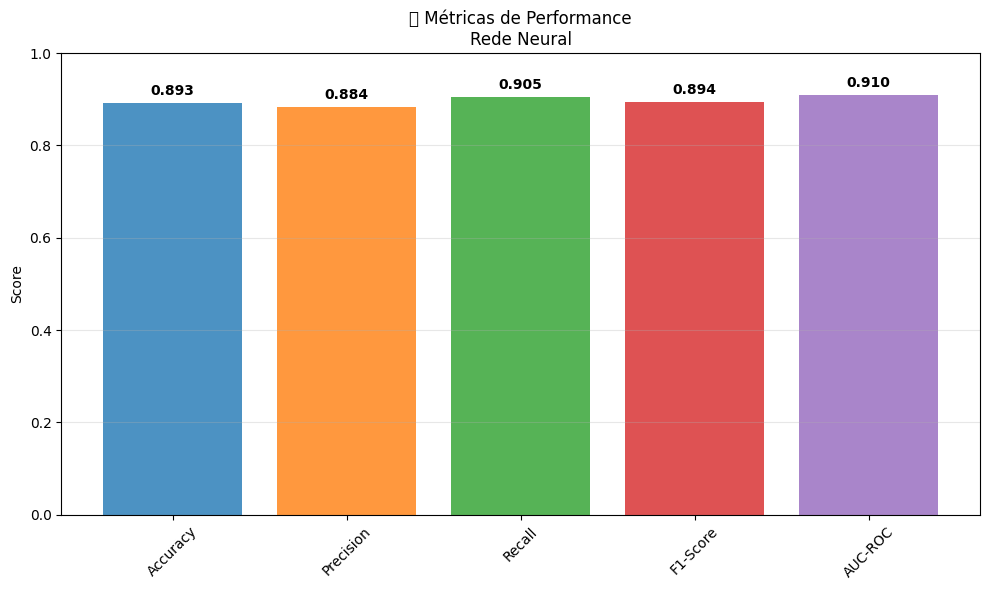

INTERPRETAÇÃO DOS RESULTADOS:
 O modelo está prevendo: Nível de Criminalidade (Baixo=0, Alto=1)
Acurácia no teste: 89.3%
AUC-ROC: 0.910 (0.5=aleatório, 1.0=perfeito)
Precisão: 88.4% (dos casos preditos como 'alta criminalidade', quantos são reais)
Recall: 90.5% (dos casos reais de 'alta criminalidade', quantos foram detectados)
 F1-Score: 0.894 (média harmônica entre precisão e recall)
 Modelo tem BOA capacidade discriminativa


In [205]:

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

plt.figure(figsize=(10, 6))
precision = precision_score(y_test_array, nn_test_pred, zero_division=0)
recall = recall_score(y_test_array, nn_test_pred, zero_division=0)
f1 = f1_score(y_test_array, nn_test_pred, zero_division=0)
auc = roc_auc_score(y_test_array, proba_flat)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
values = [eout_accuracy, precision, recall, f1, auc]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

bars = plt.bar(metrics, values, color=colors, alpha=0.8)
plt.ylim(0, 1)
plt.title('📈 Métricas de Performance\nRede Neural')
plt.ylabel('Score')

# Adicionar valores nas barras
for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Resumo interpretativo (pode rodar nesta célula ou em outra)
print("INTERPRETAÇÃO DOS RESULTADOS:")
print("="*50)
print(f" O modelo está prevendo: Nível de Criminalidade (Baixo=0, Alto=1)")
print(f"Acurácia no teste: {eout_accuracy:.1%}")
print(f"AUC-ROC: {auc:.3f} (0.5=aleatório, 1.0=perfeito)")
print(f"Precisão: {precision:.1%} (dos casos preditos como 'alta criminalidade', quantos são reais)")
print(f"Recall: {recall:.1%} (dos casos reais de 'alta criminalidade', quantos foram detectados)")
print(f" F1-Score: {f1:.3f} (média harmônica entre precisão e recall)")

if auc > 0.8:
    print(" Modelo tem BOA capacidade discriminativa")
elif auc > 0.7:
    print("  Modelo tem capacidade discriminativa MODERADA")
else:
    print(" Modelo tem capacidade discriminativa BAIXA")


## 3. Support Vector Machine Implementation

In [206]:
# 🔎 Hiperparâmetros para busca em grade
svm_params = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 1]
}

# Definir modelo e grid search
svm_model = SVC(probability=True, random_state=42)  # probability=True para permitir curvas ROC
svm_grid = GridSearchCV(svm_model, svm_params, cv=5, scoring='accuracy', n_jobs=-1)

print("Treinando SVM com Grid Search...")
svm_grid.fit(X_train_scaled, y_train)

print(f"Melhores parâmetros SVM: {svm_grid.best_params_}")
print(f"Melhor score cross-val: {svm_grid.best_score_:.4f}")


Treinando SVM com Grid Search...
Melhores parâmetros SVM: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Melhor score cross-val: 0.9819


In [207]:
best_svm = svm_grid.best_estimator_


svm_test_pred = best_svm.predict(X_test_scaled)
svm_test_pred_proba = best_svm.predict_proba(X_test_scaled)[:, 1]

svm_acc = accuracy_score(y_test, svm_test_pred)
svm_prec = precision_score(y_test, svm_test_pred)
svm_rec = recall_score(y_test, svm_test_pred)
svm_f1 = f1_score(y_test, svm_test_pred)
svm_auc = roc_auc_score(y_test, svm_test_pred_proba)

In [208]:
print("\n📊 Resultados no Conjunto de Teste (SVM):")
print(f"Acurácia: {svm_acc:.3f}")
print(f"Precisão: {svm_prec:.3f}")
print(f"Recall: {svm_rec:.3f}")
print(f"F1-Score: {svm_f1:.3f}")
print(f"AUC-ROC: {svm_auc:.3f}")



📊 Resultados no Conjunto de Teste (SVM):
Acurácia: 0.976
Precisão: 0.955
Recall: 1.000
F1-Score: 0.977
AUC-ROC: 0.999


In [209]:
print("\n📋 Classification Report:")
print(classification_report(y_test, svm_test_pred, target_names=["Baixa Criminalidade", "Alta Criminalidade"]))


📋 Classification Report:
                     precision    recall  f1-score   support

Baixa Criminalidade       1.00      0.95      0.98        42
 Alta Criminalidade       0.95      1.00      0.98        42

           accuracy                           0.98        84
          macro avg       0.98      0.98      0.98        84
       weighted avg       0.98      0.98      0.98        84



c:\Users\Lenovo\Desktop\projeto_2\ML_PROJETO_FINAL\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


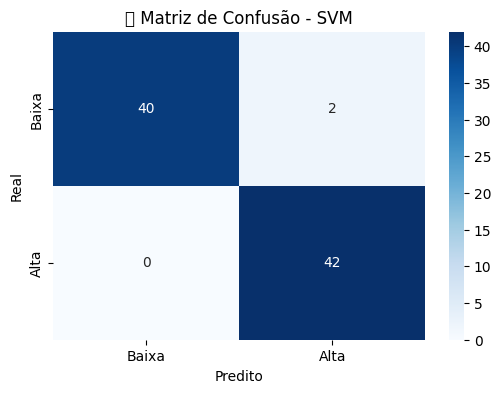

In [210]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, svm_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Baixa", "Alta"],
            yticklabels=["Baixa", "Alta"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("🔍 Matriz de Confusão - SVM")
plt.show()

In [211]:

svm_train_pred = best_svm.predict(X_train_scaled)
svm_test_pred = best_svm.predict(X_test_scaled)


svm_train_proba = best_svm.predict_proba(X_train_scaled)[:, 1]
svm_test_proba = best_svm.predict_proba(X_test_scaled)[:, 1]


acc_in = accuracy_score(y_train, svm_train_pred)
acc_out = accuracy_score(y_test, svm_test_pred)


ein = 1 - acc_in
eout = 1 - acc_out


print(f"Acurácia Treino (Ein): {acc_in:.3f}  → Erro = {ein:.3f}")
print(f"Acurácia Teste  (Eout): {acc_out:.3f}  → Erro = {eout:.3f}")


Acurácia Treino (Ein): 0.997  → Erro = 0.003
Acurácia Teste  (Eout): 0.976  → Erro = 0.024


In [212]:
# 🚨 ANÁLISE DETALHADA DE OVERFITTING - SVM
print("="*60)
print("🔍 DIAGNÓSTICO DE OVERFITTING - SVM")
print("="*60)

# Calcular Ein e Eout com mais detalhes
svm_train_pred = best_svm.predict(X_train_scaled)
svm_test_pred = best_svm.predict(X_test_scaled)

# Probabilidades para análise mais profunda
svm_train_proba = best_svm.predict_proba(X_train_scaled)[:, 1]
svm_test_proba = best_svm.predict_proba(X_test_scaled)[:, 1]

# Métricas de treino (Ein)
ein_acc = accuracy_score(y_train, svm_train_pred)
ein_prec = precision_score(y_train, svm_train_pred)
ein_rec = recall_score(y_train, svm_train_pred)
ein_f1 = f1_score(y_train, svm_train_pred)
ein_auc = roc_auc_score(y_train, svm_train_proba)

# Métricas de teste (Eout)
eout_acc = accuracy_score(y_test, svm_test_pred)
eout_prec = precision_score(y_test, svm_test_pred)
eout_rec = recall_score(y_test, svm_test_pred)
eout_f1 = f1_score(y_test, svm_test_pred)
eout_auc = roc_auc_score(y_test, svm_test_proba)

print(f"\n📊 COMPARAÇÃO Ein vs Eout:")
print(f"{'Métrica':<12} {'Ein (Treino)':<12} {'Eout (Teste)':<12} {'Diferença':<10} {'Status'}")
print("-" * 60)
print(f"{'Accuracy':<12} {ein_acc:<12.4f} {eout_acc:<12.4f} {eout_acc-ein_acc:<10.4f} {'⚠️ SUSPEITO' if abs(eout_acc-ein_acc) < 0.01 else '✅ OK'}")
print(f"{'Precision':<12} {ein_prec:<12.4f} {eout_prec:<12.4f} {eout_prec-ein_prec:<10.4f} {'⚠️ SUSPEITO' if abs(eout_prec-ein_prec) < 0.01 else '✅ OK'}")
print(f"{'Recall':<12} {ein_rec:<12.4f} {eout_rec:<12.4f} {eout_rec-ein_rec:<10.4f} {'⚠️ SUSPEITO' if abs(eout_rec-ein_rec) < 0.01 else '✅ OK'}")
print(f"{'F1-Score':<12} {ein_f1:<12.4f} {eout_f1:<12.4f} {eout_f1-ein_f1:<10.4f} {'⚠️ SUSPEITO' if abs(eout_f1-ein_f1) < 0.01 else '✅ OK'}")
print(f"{'AUC-ROC':<12} {ein_auc:<12.4f} {eout_auc:<12.4f} {eout_auc-ein_auc:<10.4f} {'⚠️ SUSPEITO' if abs(eout_auc-ein_auc) < 0.01 else '✅ OK'}")

# Alertas de overfitting
print(f"\n🚨 ALERTAS DE OVERFITTING:")
if abs(eout_acc - ein_acc) < 0.01 and eout_acc > 0.95:
    print("❌ ALTA SUSPEITA: Performance quase idêntica em treino e teste com valores muito altos!")
    print("   Possíveis causas: Data leakage, features redundantes, dataset muito pequeno")

if eout_acc > ein_acc:
    print("❌ ANÔMALO: Performance no teste MAIOR que no treino - possível data leakage!")

# Análise das probabilidades
print(f"\n📈 ANÁLISE DAS PROBABILIDADES:")
print(f"Treino - Min: {svm_train_proba.min():.4f}, Max: {svm_train_proba.max():.4f}, Std: {svm_train_proba.std():.4f}")
print(f"Teste  - Min: {svm_test_proba.min():.4f}, Max: {svm_test_proba.max():.4f}, Std: {svm_test_proba.std():.4f}")

# Contagem de predições extremas (muito confiantes)
train_extreme = np.sum((svm_train_proba < 0.1) | (svm_train_proba > 0.9))
test_extreme = np.sum((svm_test_proba < 0.1) | (svm_test_proba > 0.9))

print(f"\nPredições extremas (< 0.1 ou > 0.9):")
print(f"Treino: {train_extreme}/{len(svm_train_proba)} ({train_extreme/len(svm_train_proba)*100:.1f}%)")
print(f"Teste:  {test_extreme}/{len(svm_test_proba)} ({test_extreme/len(svm_test_proba)*100:.1f}%)")

if train_extreme/len(svm_train_proba) > 0.8:
    print("⚠️ ALERTA: Muitas predições extremas - modelo pode estar 'decorando' os dados!")

🔍 DIAGNÓSTICO DE OVERFITTING - SVM

📊 COMPARAÇÃO Ein vs Eout:
Métrica      Ein (Treino) Eout (Teste) Diferença  Status
------------------------------------------------------------
Accuracy     0.9970       0.9762       -0.0208    ✅ OK
Precision    0.9940       0.9545       -0.0394    ✅ OK
Recall       1.0000       1.0000       0.0000     ⚠️ SUSPEITO
F1-Score     0.9970       0.9767       -0.0202    ✅ OK
AUC-ROC      1.0000       0.9994       -0.0005    ⚠️ SUSPEITO

🚨 ALERTAS DE OVERFITTING:

📈 ANÁLISE DAS PROBABILIDADES:
Treino - Min: 0.0000, Max: 1.0000, Std: 0.4805
Teste  - Min: 0.0000, Max: 1.0000, Std: 0.4766

Predições extremas (< 0.1 ou > 0.9):
Treino: 316/332 (95.2%)
Teste:  77/84 (91.7%)
⚠️ ALERTA: Muitas predições extremas - modelo pode estar 'decorando' os dados!


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26060\2810274551.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



🔧 SOLUÇÃO 1: CRIANDO DATASET SEM DATA LEAKAGE


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26060\2810274551.py:29: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Lenovo\Desktop\projeto_2\ML_PROJETO_FINAL\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


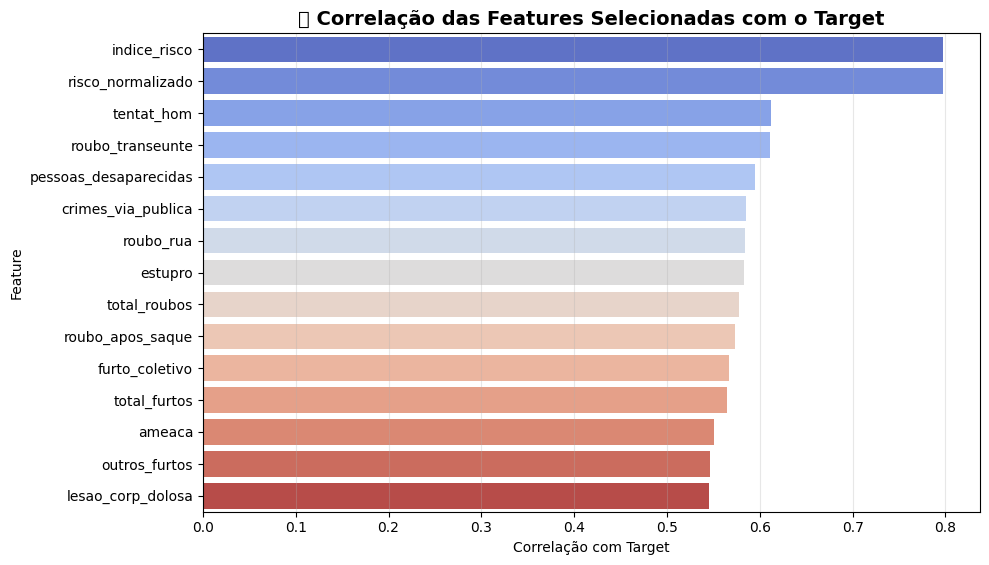


🗑️ FEATURES A SEREM REMOVIDAS (2):
  • crimes_via_publica (corr: 0.585)
  • indice_risco (corr: 0.797)

✅ NOVO DATASET CRIADO:
  • Features originais: 15
  • Features removidas: 2
  • Features finais: 13
  • Shape treino: (332, 13)
  • Shape teste: (84, 13)

🔍 FEATURES MANTIDAS:
   1. tentat_hom (corr: 0.612)
   2. lesao_corp_dolosa (corr: 0.546)
   3. estupro (corr: 0.583)
   4. roubo_transeunte (corr: 0.611)
   5. roubo_rua (corr: 0.583)
   6. roubo_apos_saque (corr: 0.574)
   7. total_roubos (corr: 0.578)
   8. furto_coletivo (corr: 0.567)
   9. outros_furtos (corr: 0.546)
  10. total_furtos (corr: 0.564)
  ... e mais 3 features


In [213]:
# 🔧 SOLUÇÃO 1: Remover Features com Data Leakage e Visualizar Correlação

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "="*60)
print("🔧 SOLUÇÃO 1: CRIANDO DATASET SEM DATA LEAKAGE")
print("="*60)

# Calcular correlação das features selecionadas com o target
corr_matrix = pd.DataFrame(X_train_scaled, columns=feature_names)
corr_matrix[target_column] = y_train.values
correlations = corr_matrix.corr()[target_column].drop(target_column)
correlations_sorted = sorted(zip(correlations.index, correlations.values), key=lambda x: abs(x[1]), reverse=True)

# Plotar gráfico de correlação das features selecionadas com o target
plt.figure(figsize=(10, 0.5 + 0.35*len(feature_names)))
sns.barplot(
    x=[c for _, c in correlations_sorted],
    y=[f for f, _ in correlations_sorted],
    palette="coolwarm",
    orient='h'
)
plt.title("🔍 Correlação das Features Selecionadas com o Target", fontsize=14, fontweight='bold')
plt.xlabel("Correlação com Target")
plt.ylabel("Feature")
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Identificar features que devem ser removidas
features_to_remove = []

# 1. Features derivadas diretamente do target
leakage_keywords = ['total_crimes', 'crimes_', 'criminalidade', 'indice_risco', 'alto_homicidio']
for feature in feature_names:
    if any(keyword in feature.lower() for keyword in leakage_keywords):
        features_to_remove.append(feature)

# 2. Features com correlação muito alta
high_corr_features = [f for f, c in correlations_sorted if abs(c) > 0.85]
for feature in high_corr_features:
    if feature not in features_to_remove:
        features_to_remove.append(feature)

print(f"\n🗑️ FEATURES A SEREM REMOVIDAS ({len(features_to_remove)}):")
for feature in features_to_remove:
    corr_value = next((c for f, c in correlations_sorted if f == feature), 0)
    print(f"  • {feature} (corr: {corr_value:.3f})")

# Criar novo dataset sem features suspeitas
if features_to_remove:
    # Encontrar índices das features a manter
    features_to_keep_idx = [i for i, feature in enumerate(feature_names)
                           if feature not in features_to_remove]
    features_to_keep_names = [feature_names[i] for i in features_to_keep_idx]

    # Criar novos conjuntos sem data leakage
    X_train_clean = X_train_scaled[:, features_to_keep_idx]
    X_test_clean = X_test_scaled[:, features_to_keep_idx]

    print(f"\n✅ NOVO DATASET CRIADO:")
    print(f"  • Features originais: {len(feature_names)}")
    print(f"  • Features removidas: {len(features_to_remove)}")
    print(f"  • Features finais: {len(features_to_keep_names)}")
    print(f"  • Shape treino: {X_train_clean.shape}")
    print(f"  • Shape teste: {X_test_clean.shape}")

    print(f"\n🔍 FEATURES MANTIDAS:")
    for i, feature in enumerate(features_to_keep_names[:10]):  # Mostrar só as 10 primeiras
        corr_value = next((c for f, c in correlations_sorted if f == feature), 0)
        print(f"  {i+1:2d}. {feature} (corr: {corr_value:.3f})")

    if len(features_to_keep_names) > 10:
        print(f"  ... e mais {len(features_to_keep_names) - 10} features")
else:
    print("✅ Nenhuma feature suspeita identificada para remoção")
    X_train_clean = X_train_scaled.copy()
    X_test_clean = X_test_scaled.copy()
    features_to_keep_names = feature_names.copy()

In [214]:
# 🔧 SOLUÇÃO 2: Testar Modelos com Dataset Limpo
print("\n" + "="*60)
print("🔧 SOLUÇÃO 2: RETREINANDO MODELOS SEM DATA LEAKAGE")
print("="*60)

# 1. Neural Network com dataset limpo
print("🧠 Treinando Neural Network (dataset limpo)...")
model_clean = tf.keras.Sequential([
    tf.keras.layers.Dense(8, input_dim=X_train_clean.shape[1], activation='relu'),
    tf.keras.layers.Dropout(0.3),  
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_clean.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Treinamento com early stopping mais agressivo
history_clean = model_clean.fit(
    X_train_clean, y_train,
    batch_size=16,  # Batch size menor
    epochs=50,      # Menos épocas
    validation_split=0.3,  # Mais dados para validação
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3)
    ],
    verbose=0
)

# Predições do modelo limpo
nn_clean_train_pred = (model_clean.predict(X_train_clean, verbose=0) > 0.5).astype(int).flatten()
nn_clean_test_pred = (model_clean.predict(X_test_clean, verbose=0) > 0.5).astype(int).flatten()

nn_clean_ein = accuracy_score(y_train, nn_clean_train_pred)
nn_clean_eout = accuracy_score(y_test, nn_clean_test_pred)

print(f"✅ Neural Network (dataset limpo):")
print(f"   Ein:  {nn_clean_ein:.4f}")
print(f"   Eout: {nn_clean_eout:.4f}")
print(f"   Diferença: {abs(nn_clean_eout - nn_clean_ein):.4f}")

# 2. SVM com dataset limpo
print(f"\n🎯 Treinando SVM (dataset limpo)...")
svm_clean = SVC(C=1.0, kernel='rbf', gamma='scale', probability=True, random_state=42)
svm_clean.fit(X_train_clean, y_train)

svm_clean_train_pred = svm_clean.predict(X_train_clean)
svm_clean_test_pred = svm_clean.predict(X_test_clean)

svm_clean_ein = accuracy_score(y_train, svm_clean_train_pred)
svm_clean_eout = accuracy_score(y_test, svm_clean_test_pred)

print(f"✅ SVM (dataset limpo):")
print(f"   Ein:  {svm_clean_ein:.4f}")
print(f"   Eout: {svm_clean_eout:.4f}")
print(f"   Diferença: {abs(svm_clean_eout - svm_clean_ein):.4f}")

# 3. Decision Tree com regularização
print(f"\n🌳 Treinando Decision Tree (regularizado)...")
dt_clean = DecisionTreeClassifier(
    max_depth=5,        # Limitar profundidade
    min_samples_split=10,  # Mínimo de amostras para split
    min_samples_leaf=5,    # Mínimo de amostras por folha
    max_features='sqrt',   # Limitar features por split
    random_state=42
)
dt_clean.fit(X_train_clean, y_train)

dt_clean_train_pred = dt_clean.predict(X_train_clean)
dt_clean_test_pred = dt_clean.predict(X_test_clean)

dt_clean_ein = accuracy_score(y_train, dt_clean_train_pred)
dt_clean_eout = accuracy_score(y_test, dt_clean_test_pred)

print(f"✅ Decision Tree (regularizado):")
print(f"   Ein:  {dt_clean_ein:.4f}")
print(f"   Eout: {dt_clean_eout:.4f}")
print(f"   Diferença: {abs(dt_clean_eout - dt_clean_ein):.4f}")


🔧 SOLUÇÃO 2: RETREINANDO MODELOS SEM DATA LEAKAGE
🧠 Treinando Neural Network (dataset limpo)...


c:\Users\Lenovo\Desktop\projeto_2\ML_PROJETO_FINAL\.venv\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Neural Network (dataset limpo):
   Ein:  0.8795
   Eout: 0.8929
   Diferença: 0.0133

🎯 Treinando SVM (dataset limpo)...
✅ SVM (dataset limpo):
   Ein:  0.9247
   Eout: 0.9405
   Diferença: 0.0158

🌳 Treinando Decision Tree (regularizado)...
✅ Decision Tree (regularizado):
   Ein:  0.9789
   Eout: 0.9524
   Diferença: 0.0265


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26060\1132933026.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26060\1132933026.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


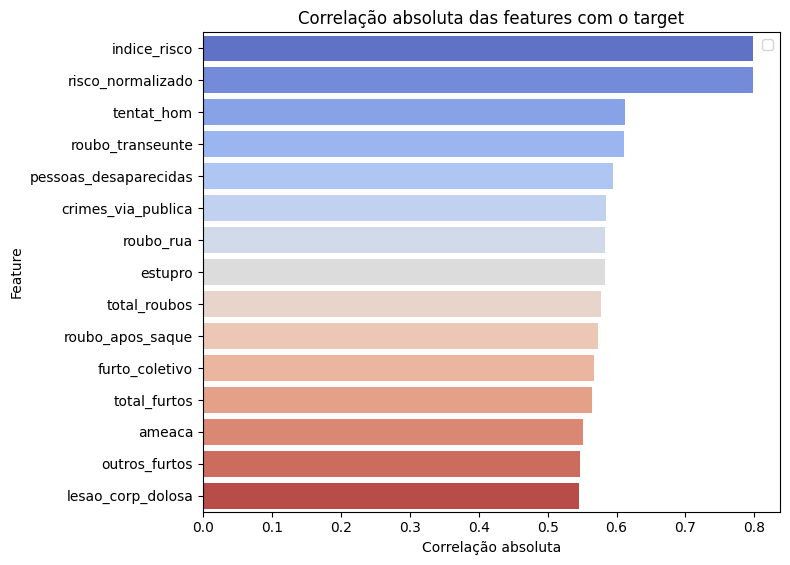

In [215]:
# Gráfico de correlação absoluta das features com o target (justificativa para remoção)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 0.5 + 0.35*len(feature_names)))
corr_abs = [abs(c) for _, c in correlations_sorted]
sns.barplot(
    x=corr_abs,
    y=[f for f, _ in correlations_sorted],
    palette="coolwarm",
    orient='h'
)
plt.title("Correlação absoluta das features com o target")
plt.xlabel("Correlação absoluta")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()


In [216]:
# Identificar features que devem ser removidas
features_to_remove = []

# 1. Features derivadas diretamente do target
leakage_keywords = ['total_crimes', 'crimes_', 'criminalidade', 'indice_risco', 'alto_homicidio']
for feature in feature_names:
    if any(keyword in feature.lower() for keyword in leakage_keywords):
        features_to_remove.append(feature)

# 2. Features com correlação muito alta
high_corr_features = [f for f, c in correlations_sorted if abs(c) > 0.85]
for feature in high_corr_features:
    if feature not in features_to_remove:
        features_to_remove.append(feature)

# Criar novo dataset sem features suspeitas
if features_to_remove:
    features_to_keep_idx = [i for i, feature in enumerate(feature_names)
                            if feature not in features_to_remove]
    features_to_keep_names = [feature_names[i] for i in features_to_keep_idx]

    X_train_clean = X_train_scaled[:, features_to_keep_idx]
    X_test_clean = X_test_scaled[:, features_to_keep_idx]
else:
    X_train_clean = X_train_scaled.copy()
    X_test_clean = X_test_scaled.copy()
    features_to_keep_names = feature_names.copy()

In [217]:
print("\n🌳 Treinando Decision Tree (após nova filtragem)...")
dt_clean = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
dt_clean.fit(X_train_clean, y_train)

dt_clean_train_pred = dt_clean.predict(X_train_clean)
dt_clean_test_pred = dt_clean.predict(X_test_clean)

dt_clean_ein = accuracy_score(y_train, dt_clean_train_pred)
dt_clean_eout = accuracy_score(y_test, dt_clean_test_pred)

print(f"✅ Decision Tree (após filtragem):")
print(f"   Ein:  {dt_clean_ein:.4f}")
print(f"   Eout: {dt_clean_eout:.4f}")
print(f"   Diferença: {abs(dt_clean_eout - dt_clean_ein):.4f}")


🌳 Treinando Decision Tree (após nova filtragem)...
✅ Decision Tree (após filtragem):
   Ein:  0.9789
   Eout: 0.9524
   Diferença: 0.0265
